## COVID Drivers: Modeling

This notebook models POST_COVID ~ AGGRESSIVE_DRIVING

### Table of Contents
* [Read the Data](#read)</BR>
* [Preprocessing](#prep)</BR>
* [Random Forest Classifier](#rfc)</BR>
* [Random Forest Classifier with GridSearchCV](#rf-gs)
* [Review Models](#review)


Import packages

In [26]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import os

import xgboost as xgb
from functools import reduce
#import prince

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_sm.csv'

In [ ]:
path_out = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/models/metrics_06_modl_rfc.csv'

### <a id='read'>Read the data</a>

In [47]:
df_init = pd.read_csv(path_in, low_memory=False)

In [48]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [49]:
df = df_init.set_index('CRASH_DATE').drop(columns=['CRN']).copy()

In [50]:
model_metrics = []

In [51]:
df.columns.tolist()

['URBAN_RURAL',
 'POST_COVID',
 'AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

### <a id='prep'>Preprocessing</a>

In [52]:
X = df.loc[:,['POST_COVID']].copy()

In [53]:
y = df['AGGRESSIVE_DRIVING']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
categorical_cols = ['URBAN_RURALx']

In [56]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols)
    ])

### <a id='rfc'>Random Forest Classifier</a>

In [58]:
rf_pipeline = Pipeline(steps=[
    #('preprocessor', preprocessor),
    ('random_forest', RandomForestClassifier(random_state=42))
])

In [59]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('random_forest', RandomForestClassifier(random_state=42))])

In [60]:
y_pred = rf_pipeline.predict(X_test)


In [61]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.97%


In [62]:
conf_matrix = confusion_matrix(y_test, y_pred)

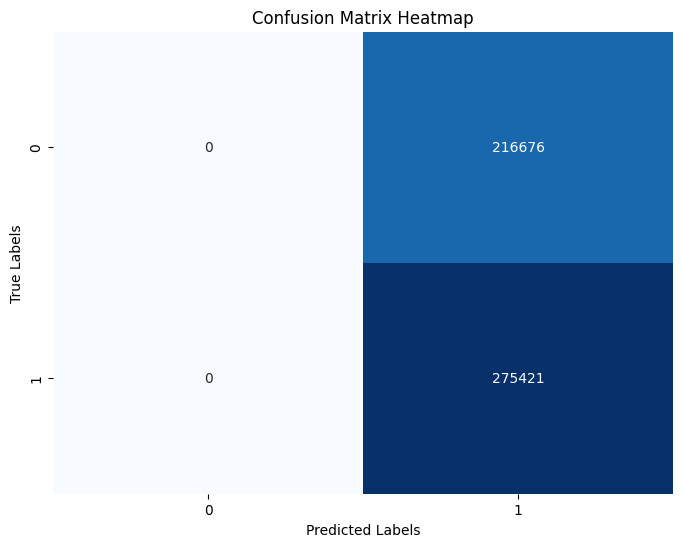

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [64]:
# Predicted probabilities for the class 1
y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [65]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [66]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [67]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [68]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [69]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier'

In [70]:
aggdrv_rf = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [71]:
aggdrv_rf['RandomForestClassifier'] = [round(x, 4) for x in aggdrv_rf['RandomForestClassifier']]

In [72]:
aggdrv_rf

,Measure,RandomForestClassifier
0,Accuracy,0.5597
1,Precision,0.5597
2,Recall,1.0000
3,F1 Score,0.7177
4,ROC AUC,0.5039


In [73]:
model_metrics.append(aggdrv_rf)

In [74]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216676
           1       0.56      1.00      0.72    275421

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### <a id='rf-gs'>Random Forest Classifier with GridSearchCV</a>

In [82]:
rf = RandomForestClassifier(random_state=42)

In [83]:
param_grid = {
    #'n_estimators': [50, 100],
    #'n_estimators': [50, 70],
    'n_estimators': [25, 50],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5, 8]
}

In [86]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=10, scoring='f1', refit=True)

In [87]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5], 'min_samples_split': [2, 5, 8],
                         'n_estimators': [25, 50]},
             scoring='f1')

In [88]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 25}

In [89]:
y_pred = grid_search.predict(X_test)

In [90]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 55.97%


In [91]:
# Predicted probabilities for the class 1
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

In [92]:
# Precision: tp / (tp + fp)
precision = precision_score(y_test, y_pred)

In [93]:
# Recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)

In [94]:
# F1-score: harmonic mean of precision and recall
f1 = f1_score(y_test, y_pred)

In [95]:
# ROC AUC: Area Under the Receiver Operating Characteristic Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [96]:
measure_titles = ['Accuracy','Precision','Recall','F1 Score','ROC AUC']
measure_value = [accuracy,precision,recall,f1,roc_auc]
model = 'RandomForestClassifier_GridSearchCV'

In [97]:
aggdrv_rfcv = pd.DataFrame({'Measure':measure_titles,
                            model:measure_value})

In [98]:
aggdrv_rfcv['RandomForestClassifier_GridSearchCV'] = [round(x, 4) for x in aggdrv_rfcv['RandomForestClassifier_GridSearchCV']]

In [99]:
aggdrv_rfcv

,Measure,RandomForestClassifier_GridSearchCV
0,Accuracy,0.5597
1,Precision,0.5597
2,Recall,1.0000
3,F1 Score,0.7177
4,ROC AUC,0.5039


In [ ]:
model_metrics.append(aggdrv_rfcv)

In [ ]:
# Comprehensive classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00    216676
           1       0.56      1.00      0.72    275421

    accuracy                           0.56    492097
   macro avg       0.28      0.50      0.36    492097
weighted avg       0.31      0.56      0.40    492097



/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lisaover/Documents/_MDS/_Case_Studies/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### <a id='review'>Review Models</a>

In [ ]:
merged_metrics = reduce(lambda left, right: pd.merge(left, right, on='Measure', how='inner'), model_metrics)

In [1]:
merged_metrics

NameError: name 'merged_metrics' is not defined

In [ ]:
merged_metrics.to_csv(path_out, index=False)